# **Precios de la vivienda** 🏠
Desarrollé un modelo predictivo utilizando el dataset House Prices de Kaggle, aplicando un pipeline completo de Data Science: limpieza de datos, imputación de valores faltantes, ingeniería de variables y selección de features mediante Mutual Information. Posteriormente, optimicé el modelo con XGBoost y GridSearchCV, logrando mejorar su capacidad predictiva.

Este proyecto me permitió fortalecer habilidades en análisis de datos, modelado y optimización, aplicando buenas prácticas de trabajo reproducible y enfoque orientado a resultados.

# Importar librerias

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor

# Leer los archivos

In [48]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# Vision General

In [49]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [50]:
df_train.shape

(1460, 81)

In [51]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Valores duplicados

In [52]:
df_train.duplicated().sum()

np.int64(0)

Identificando los valores nulos

In [53]:
pd.set_option('display.max_rows', None)
df_train.isnull().sum().sort_values(ascending = False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


# Comparar:

columnas con nulos en test

In [54]:
df_test.isnull().sum().sort_values(ascending = False)

,0
PoolQC,1456
MiscFeature,1408
Alley,1352
Fence,1169
MasVnrType,894
FireplaceQu,730
LotFrontage,227
GarageYrBlt,78
GarageCond,78
GarageFinish,78


# Conclusion
Eliminar las variables PoolQC,MiscFeauture,Alley,Fence,MasVnrType, FirePlaceQU tienen demasiados nulos

In [55]:
df_train.drop(columns=['PoolQC','MiscFeature','Alley','Fence','MasVnrType', 'FireplaceQu'], inplace=True)
df_test.drop(columns=['PoolQC','MiscFeature','Alley','Fence','MasVnrType', 'FireplaceQu'], inplace=True)

# Separar la variable objetivo
“Con estas características (X), aprendé a predecir el precio (y)”

In [56]:
X=df_train.drop(columns=['SalePrice'])
y=df_train.SalePrice


# Limpieza de datos
✔ Numéricos → median (más robusto)
✔ Categóricos → moda

In [57]:
imputer = SimpleImputer(strategy='most_frequent', fill_value="most_frequent")
imputed_X_train = pd.DataFrame(imputer.fit_transform(X))

# imputar valores nulos por moda en df_test
imputed_df_test = pd.DataFrame(imputer.transform(df_test))
imputed_df_test.columns = df_test.columns

imputed_X_train.columns = X.columns

In [58]:
pd.reset_option('display.max_rows')
imputed_X_train.isnull().sum().sort_values(ascending = False)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


# Transformar variables categoricas a numericas

In [59]:
from sklearn.preprocessing import OrdinalEncoder

# identificar columnas categóricas
object_cols = imputed_X_train.select_dtypes(include='object').columns.tolist()

# crear encoder
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# ajustar con train + test para evitar errores por categorías nuevas
ordinal_encoder.fit(pd.concat([imputed_X_train[object_cols], imputed_df_test[object_cols]], axis=0))

# transformar
imputed_X_train[object_cols] = ordinal_encoder.transform(imputed_X_train[object_cols])
imputed_df_test[object_cols] = ordinal_encoder.transform(imputed_df_test[object_cols])

# Medir qué variables ayudan más a predecir el precio de la casa
Qué tan relacionada está cada variable con el precio.
0.5 → muy importante
0.1 → poco importante
0 → no aporta nada

In [60]:
from sklearn.feature_selection import mutual_info_regression

pd.set_option('display.max_rows', None)

mi_scores = mutual_info_regression(imputed_X_train, y, random_state=42)
mi_series = pd.Series(mi_scores, index=imputed_X_train.columns)
mi_series_sorted = mi_series.sort_values(ascending=False)

print(mi_series_sorted)

OverallQual      0.568143
Neighborhood     0.520508
GrLivArea        0.482321
GarageArea       0.373745
TotalBsmtSF      0.368199
YearBuilt        0.367588
GarageCars       0.355744
KitchenQual      0.336318
ExterQual        0.328653
BsmtQual         0.321468
1stFlrSF         0.297863
MSSubClass       0.272708
FullBath         0.261910
GarageYrBlt      0.251791
GarageFinish     0.241359
YearRemodAdd     0.238482
TotRmsAbvGrd     0.216052
2ndFlrSF         0.195346
Foundation       0.195068
Fireplaces       0.172503
LotFrontage      0.170919
LotArea          0.163823
HeatingQC        0.160210
Exterior2nd      0.159480
BsmtFinType1     0.147626
BsmtFinSF1       0.141867
OpenPorchSF      0.140435
Exterior1st      0.136152
MSZoning         0.134305
GarageType       0.125770
BsmtUnfSF        0.120782
OverallCond      0.116144
WoodDeckSF       0.100946
MasVnrArea       0.099502
HalfBath         0.096998
LotShape         0.090829
HouseStyle       0.077314
SaleType         0.074947
SaleConditio

# Seleccion de variable

ordenar las variables según qué tan importantes son para predecir el precio

In [61]:
pd.set_option('display.max_rows', None)
mi_scores = mutual_info_regression(imputed_X_train, y)
mi_series = pd.Series(mi_scores, index=imputed_X_train.columns)
mi_series_sorted = mi_series.sort_values(ascending=False)

print(mi_series_sorted)

OverallQual      0.557721
Neighborhood     0.517963
GrLivArea        0.480559
GarageArea       0.375740
GarageCars       0.374529
TotalBsmtSF      0.366401
YearBuilt        0.361648
KitchenQual      0.337112
BsmtQual         0.327587
ExterQual        0.320522
1stFlrSF         0.295532
MSSubClass       0.284613
FullBath         0.268278
GarageFinish     0.260376
GarageYrBlt      0.249245
YearRemodAdd     0.245837
TotRmsAbvGrd     0.203761
2ndFlrSF         0.203284
Foundation       0.196351
Fireplaces       0.174229
Exterior2nd      0.165136
LotFrontage      0.164636
LotArea          0.164125
HeatingQC        0.156512
BsmtFinSF1       0.149904
OpenPorchSF      0.149285
BsmtFinType1     0.140348
GarageType       0.131309
Exterior1st      0.125398
MSZoning         0.122626
WoodDeckSF       0.121683
BsmtUnfSF        0.119938
OverallCond      0.101010
MasVnrArea       0.099323
LotShape         0.097133
HalfBath         0.096968
HouseStyle       0.084167
SaleCondition    0.083302
BedroomAbvGr

<Axes: >

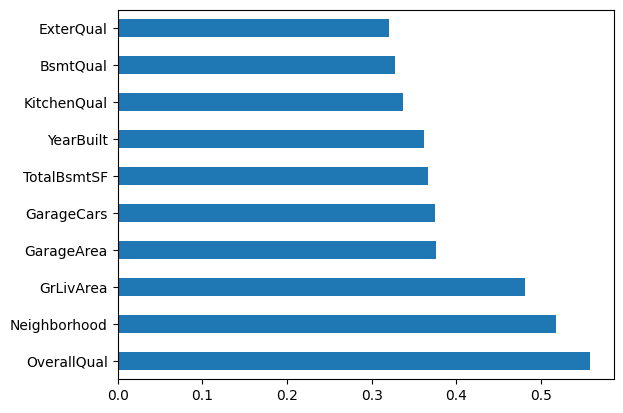

In [62]:
mi_series_sorted.head(10).plot.barh()

# Feature Engineering
nuevas variables más inteligentes
todo lo que se crea en train → replicar en test

In [63]:
imputed_X_train['ageAtRemod'] = imputed_X_train['YrSold']- imputed_X_train['YearRemodAdd']
imputed_X_train['ageAtSold'] = imputed_X_train['YrSold']-imputed_X_train['YearBuilt']
imputed_X_train['TotalBathrooms'] = imputed_X_train['BsmtFullBath'] + imputed_X_train['BsmtHalfBath'] + imputed_X_train['FullBath'] + imputed_X_train['HalfBath']
imputed_X_train['TotalPorchSF'] = imputed_X_train['OpenPorchSF'] + imputed_X_train['EnclosedPorch'] + imputed_X_train['3SsnPorch'] + imputed_X_train['ScreenPorch']
imputed_df_test['ageAtRemod'] = imputed_df_test['YrSold']- imputed_df_test['YearRemodAdd']
imputed_df_test['ageAtSold'] = imputed_df_test['YrSold']-imputed_df_test['YearBuilt']
imputed_df_test['TotalBathrooms'] = imputed_df_test['BsmtFullBath'] + imputed_df_test['BsmtHalfBath'] + imputed_df_test['FullBath'] + imputed_df_test['HalfBath']
imputed_df_test['TotalPorchSF'] = imputed_df_test['OpenPorchSF'] + imputed_df_test['EnclosedPorch'] + imputed_df_test['3SsnPorch'] + imputed_df_test['ScreenPorch']

# Medir qué variables influyen más en el precio de la casa. Regresion

In [64]:
mi_scores = mutual_info_regression(imputed_X_train, y)
mi_series = pd.Series(mi_scores, index=imputed_X_train.columns)
mi_series_sorted = mi_series.sort_values(ascending=False)

print(mi_series_sorted)

OverallQual       0.570048
Neighborhood      0.507258
GrLivArea         0.483224
GarageArea        0.377254
TotalBsmtSF       0.368851
YearBuilt         0.362326
GarageCars        0.346824
ageAtSold         0.340222
ExterQual         0.339267
KitchenQual       0.325976
BsmtQual          0.323141
TotalBathrooms    0.310956
1stFlrSF          0.295667
MSSubClass        0.278112
ageAtRemod        0.260083
FullBath          0.252085
GarageYrBlt       0.250574
YearRemodAdd      0.244016
GarageFinish      0.241874
TotRmsAbvGrd      0.226662
Foundation        0.207899
2ndFlrSF          0.196459
LotArea           0.166441
Exterior2nd       0.162886
LotFrontage       0.161936
HeatingQC         0.160616
Fireplaces        0.155489
OpenPorchSF       0.148951
BsmtFinSF1        0.145165
BsmtFinType1      0.141983
Exterior1st       0.130476
GarageType        0.121194
BsmtUnfSF         0.120606
WoodDeckSF        0.116670
MSZoning          0.114053
OverallCond       0.112449
MasVnrArea        0.104181
L

# Filtra y se queda solo con las variables realmente útiles según Mutual Information.

In [65]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# columnas categóricas
object_cols = imputed_X_train.select_dtypes(include='object').columns.tolist()

# encoder
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# ajustar con train + test
ordinal_encoder.fit(pd.concat([imputed_X_train[object_cols], imputed_df_test[object_cols]], axis=0))

# transformar
imputed_X_train[object_cols] = ordinal_encoder.transform(imputed_X_train[object_cols])
imputed_df_test[object_cols] = ordinal_encoder.transform(imputed_df_test[object_cols])

Agarrar los valores que estan encima del umbral de 0.20

In [66]:
relevant_features_mask = mi_series_sorted > 0.20

relevant_columns = mi_series_sorted[relevant_features_mask].index.tolist()

df_relevant = imputed_X_train[relevant_columns]
df_test_relevant=imputed_df_test[relevant_columns]

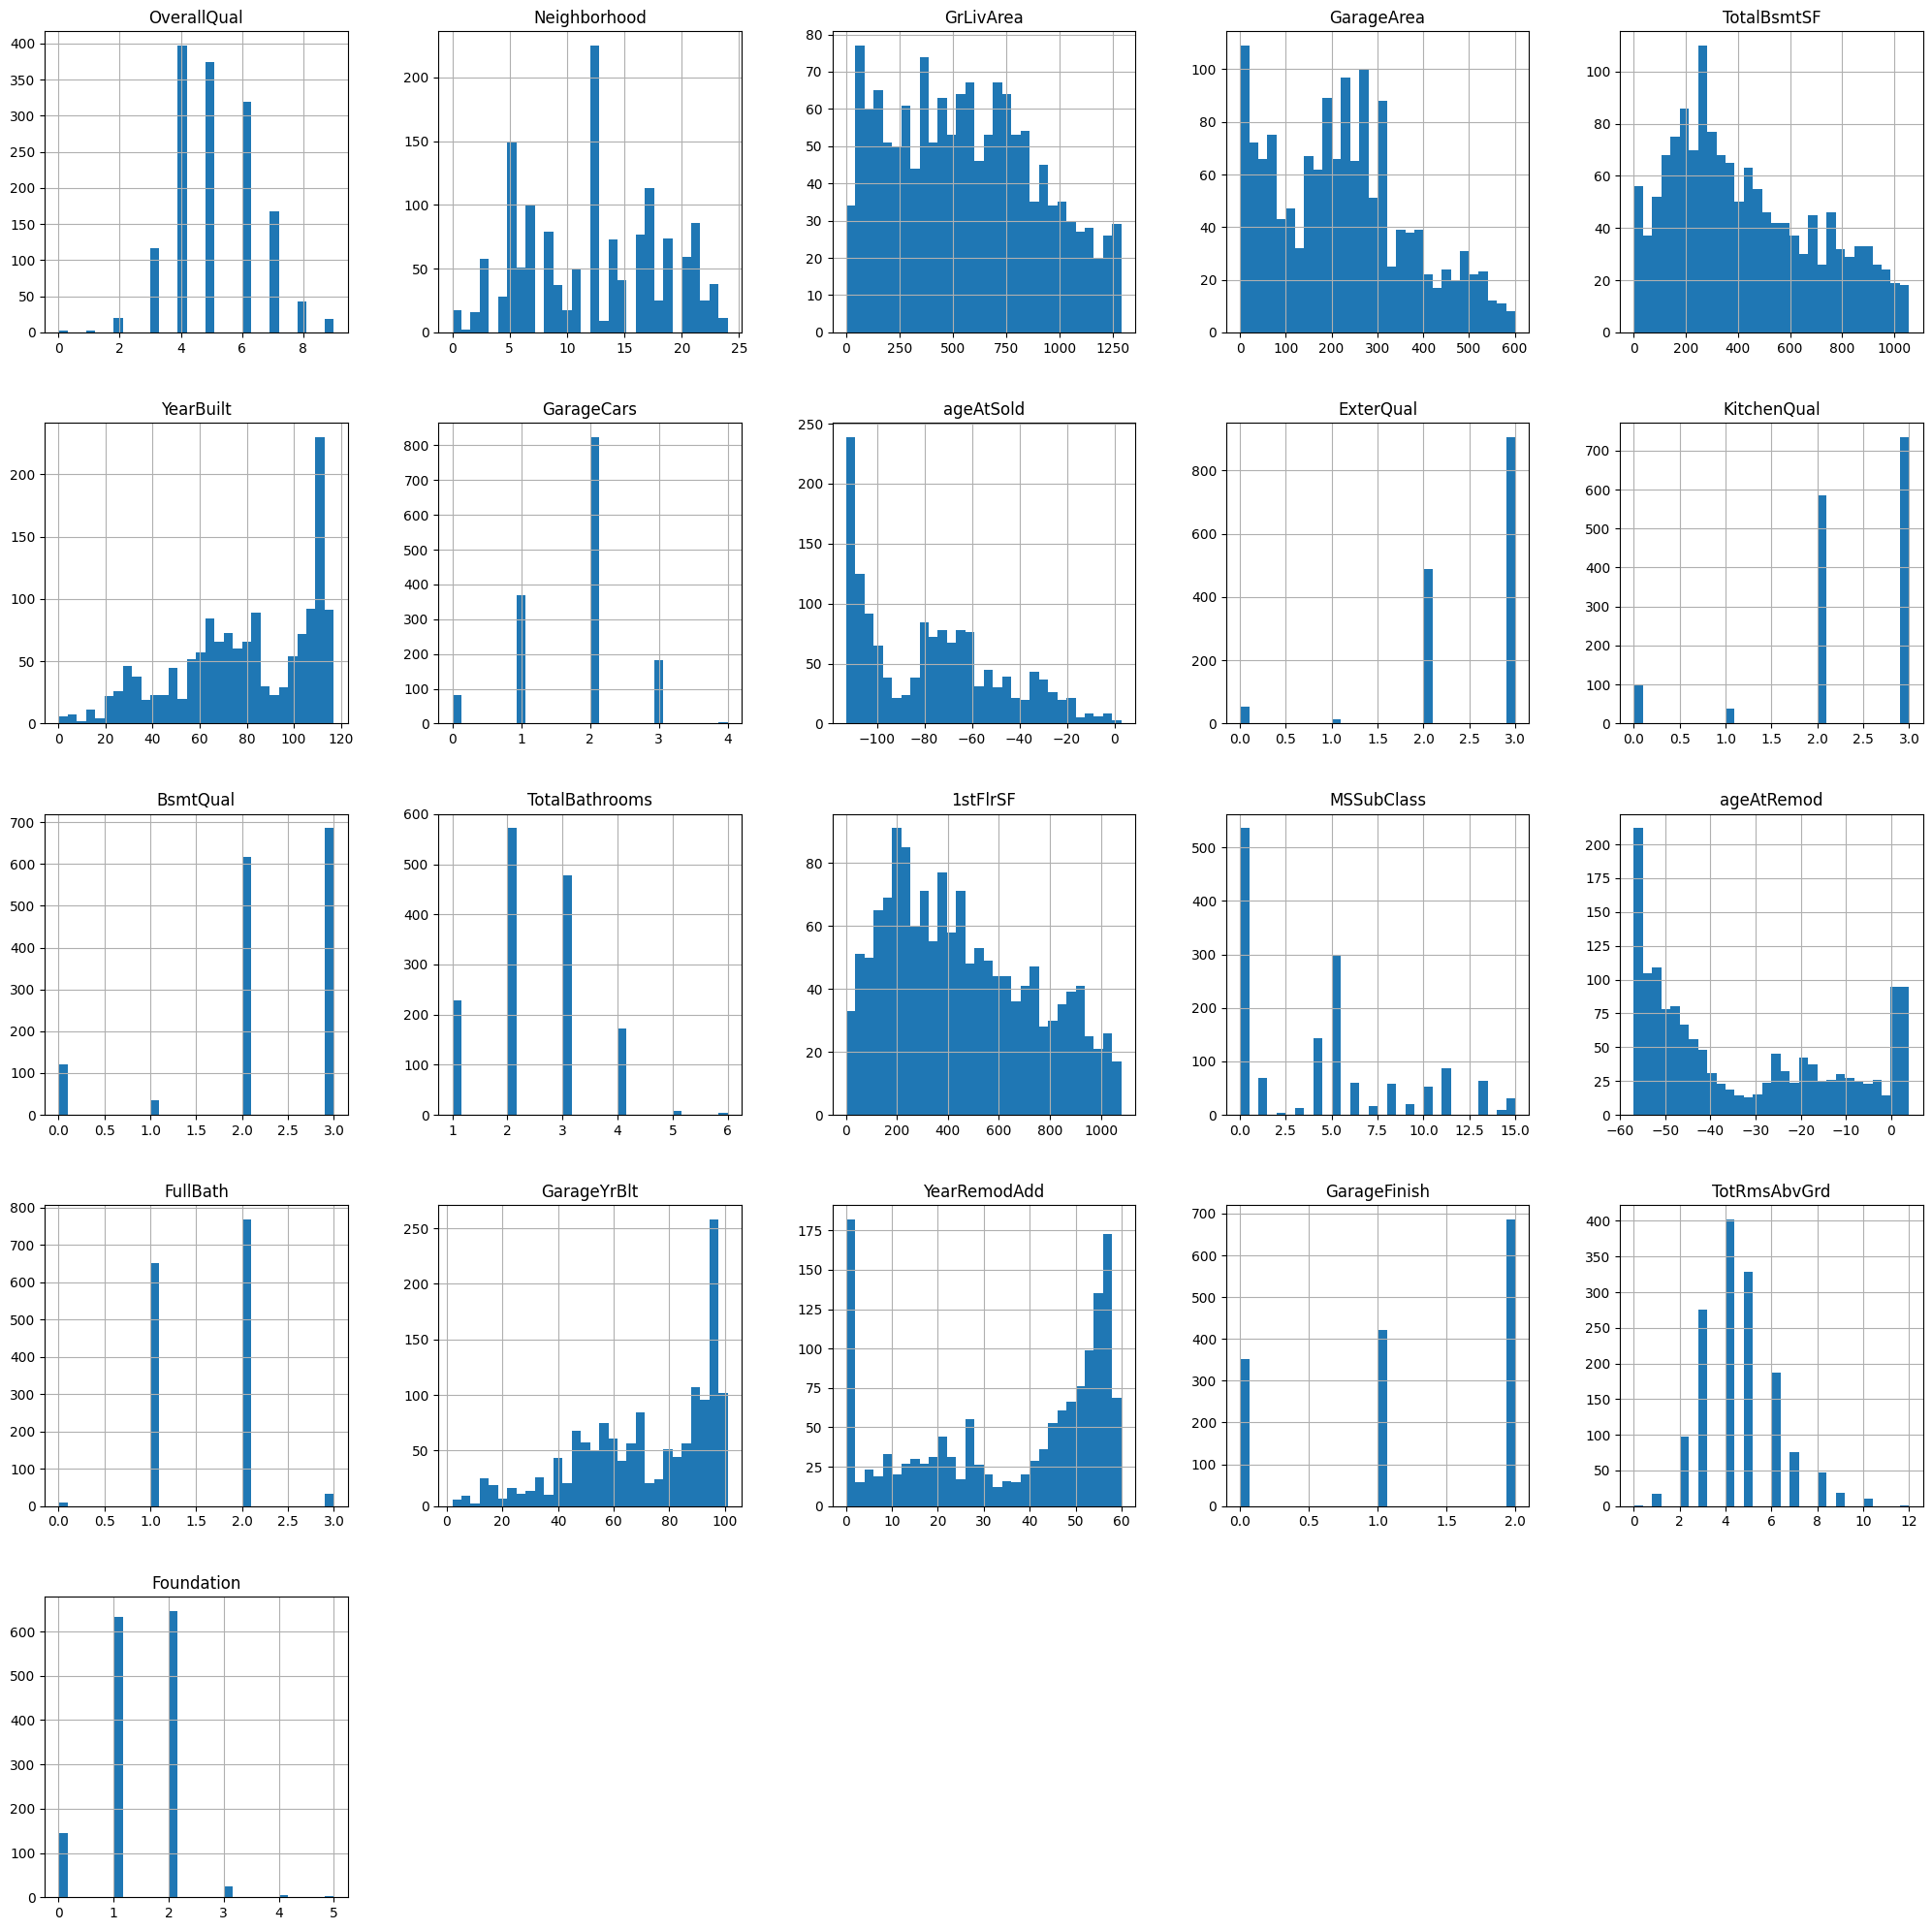

In [67]:
df_relevant.select_dtypes(['int64', 'float64']).hist(figsize = (25,25), bins = 30)
plt.show()

# Escalar
Se aplicó normalización Min-Max para escalar variables y mejorar el rendimiento del modelo. Convertio todos los valores entre 0 y 1

In [68]:
scaler=MinMaxScaler()
df_relevant= pd.DataFrame(scaler.fit_transform(df_relevant))
df_test_relevant= pd.DataFrame(scaler.transform(df_test_relevant))

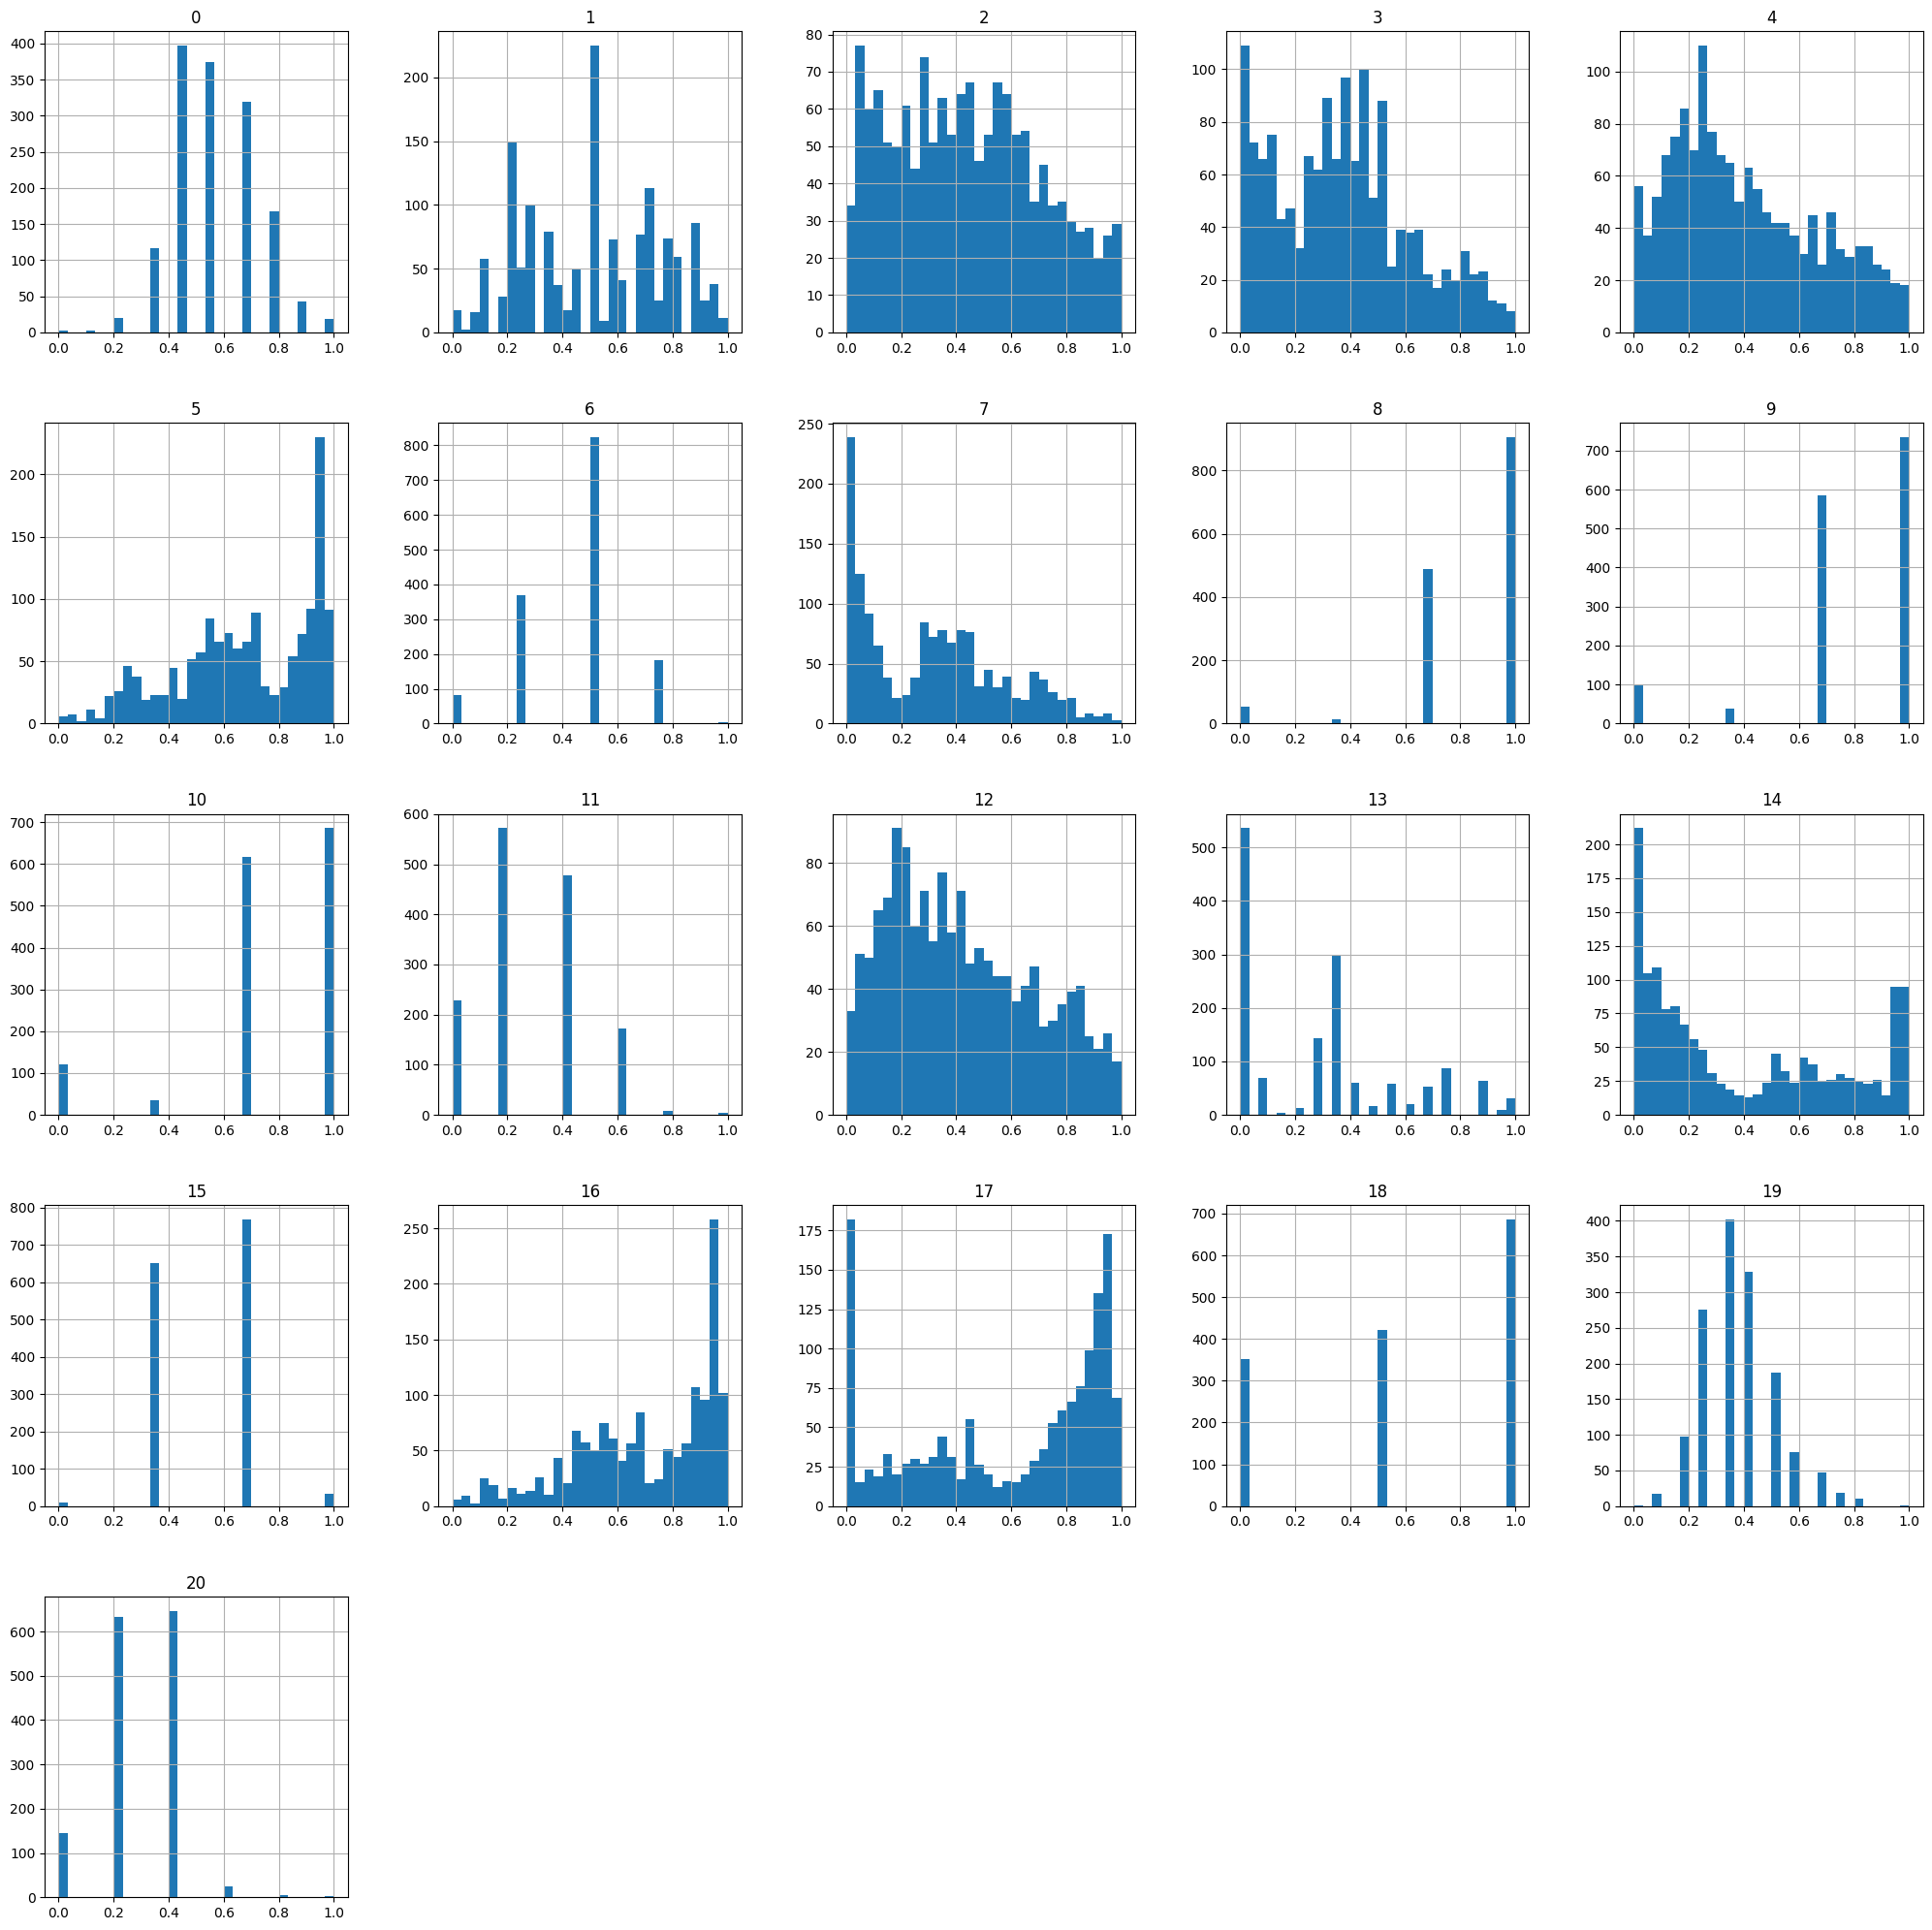

In [69]:
df_relevant.select_dtypes(['int64', 'float64']).hist(figsize = (25,25), bins = 30)
plt.show()

Ahora vemos los rangos de 0 a 1

# Modelo
dividiremos los datos para entrenar el modelo

In [70]:
X_train, X_valid, y_train, y_valid = train_test_split(df_relevant, y, train_size=0.9, test_size=0.1,
                                                      random_state=0)

buscar la mejor combinación de parámetros para el modelo XGBoost

In [71]:
param_grid = {
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100],

}
#Definir combinaciones de parámetros

estimator = XGBRegressor()

optimal_params = GridSearchCV(estimator=estimator, param_grid=param_grid, verbose=0)
optimal_params.fit(X_train, y_train, verbose=False)

model= optimal_params.best_estimator_

In [72]:
df_test_rel=imputed_df_test[relevant_columns]

df_test_rel.head()

,OverallQual,Neighborhood,GrLivArea,GarageArea,TotalBsmtSF,YearBuilt,GarageCars,ageAtSold,ExterQual,KitchenQual,...,TotalBathrooms,1stFlrSF,MSSubClass,ageAtRemod,FullBath,GarageYrBlt,YearRemodAdd,GarageFinish,TotRmsAbvGrd,Foundation
0,4.0,12.0,101.0,428.0,279.0,68.0,1.0,-64.0,3.0,3.0,...,1.0,233.0,0.0,-7.0,1.0,52.0,11.0,2.0,3.0,1.0
1,5.0,12.0,439.0,85.0,652.0,65.0,1.0,-61.0,3.0,2.0,...,2.0,619.0,0.0,-4.0,1.0,49.0,8.0,2.0,4.0,1.0
2,4.0,8.0,696.0,224.0,314.0,104.0,2.0,-100.0,3.0,3.0,...,3.0,261.0,5.0,-44.0,2.0,88.0,48.0,0.0,4.0,2.0
3,5.0,8.0,674.0,212.0,312.0,105.0,2.0,-101.0,3.0,2.0,...,3.0,259.0,5.0,-44.0,2.0,89.0,48.0,0.0,5.0,2.0
4,7.0,22.0,398.0,246.0,618.0,99.0,2.0,-95.0,2.0,2.0,...,2.0,578.0,11.0,-38.0,2.0,83.0,42.0,1.0,3.0,2.0


In [73]:
df_test_rel.isnull().sum()

,0
OverallQual,0
Neighborhood,0
GrLivArea,0
GarageArea,0
TotalBsmtSF,0
YearBuilt,0
GarageCars,0
ageAtSold,0
ExterQual,0
KitchenQual,0


In [74]:
predicciones = model.predict(df_test_relevant)
df_test['SalePrice'] = predicciones
df= df_test[['Id','SalePrice']]
df.head(10)

,Id,SalePrice
0,1461,120028.257812
1,1462,153148.343750
2,1463,163349.640625
3,1464,180905.093750
4,1465,193133.656250
5,1466,178584.187500
6,1467,170274.765625
7,1468,170711.968750
8,1469,185343.859375
9,1470,122107.984375


# Precios de la vivienda


In [75]:
df.to_csv('submission.csv', index=False)